In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

# Importing the objective function history (each row is an average of 4 replicates)
objFunctionHistory_stepwise = []

for idx in range(6):
    objFunctionHistory_stepwise.append([])

for idx in range(2, 6):
    stepNo = idx + 1
    objFunctionHistory_stepwise[idx] = pd.read_csv(f'BSearchresults_GA_step{stepNo}.objectiveFunctionHistory.csv')
    print(f"And now we have step {stepNo}")
    print(objFunctionHistory_stepwise[idx])
    print(" THATS ALL FOLKS ")



And now we have step 3
     search-number  evaluation  number_of_agents*  \
0                1           4               1000   
1                1           8               1000   
2                1          12               1000   
3                1          16               1000   
4                1          20               1000   
..             ...         ...                ...   
140              1         564               1000   
141              1         568               1000   
142              1         572               1000   
143              1         576               1000   
144              1         580               1000   

     number_of_opinion_dimensions* model*  boundary_mean*  set-seed?*  \
0                                1   "HK"            0.03       False   
1                                1   "HK"            0.05       False   
2                                1   "HK"            0.26       False   
3                                1   "HK"       

In [5]:
objFunctionHistory_stepwise

[[],
 [],
 [],
      search-number  evaluation  number_of_agents*  \
 0                1           4               1000   
 1                1           8               1000   
 2                1          12               1000   
 3                1          16               1000   
 4                1          20               1000   
 ..             ...         ...                ...   
 370              1        1484               1000   
 371              1        1488               1000   
 372              1        1492               1000   
 373              1        1496               1000   
 374              1        1500               1000   
 
      number_of_opinion_dimensions* model*  boundary_mean*  set-seed?*  \
 0                                1   "HK"            0.29       False   
 1                                1   "HK"            0.20       False   
 2                                1   "HK"            0.13       False   
 3                                1   "

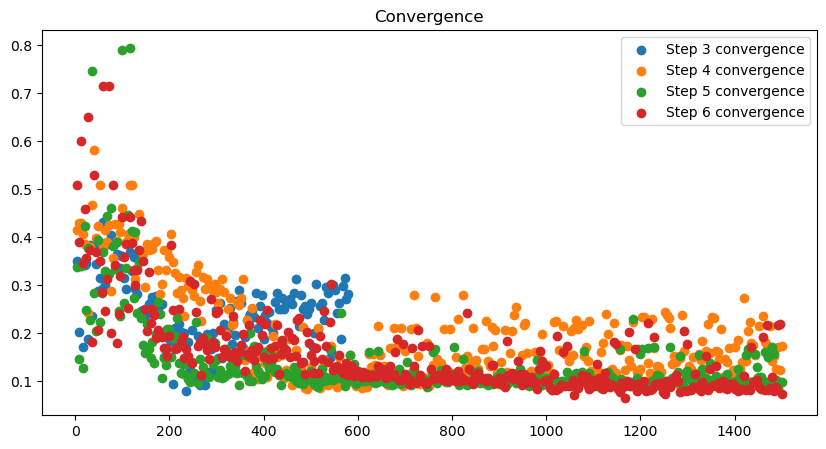

In [18]:
plt.figure(figsize=(10,5))

for idx in range(2, 6):
    stepNo = idx + 1
    x = objFunctionHistory_stepwise[idx]["evaluation"]
    y = objFunctionHistory_stepwise[idx]["fitness"]

    plt.scatter(x,y, label=(f'Step {stepNo} convergence'))
    plt.title('Raw Convergence')
    # plt.
    plt.legend()

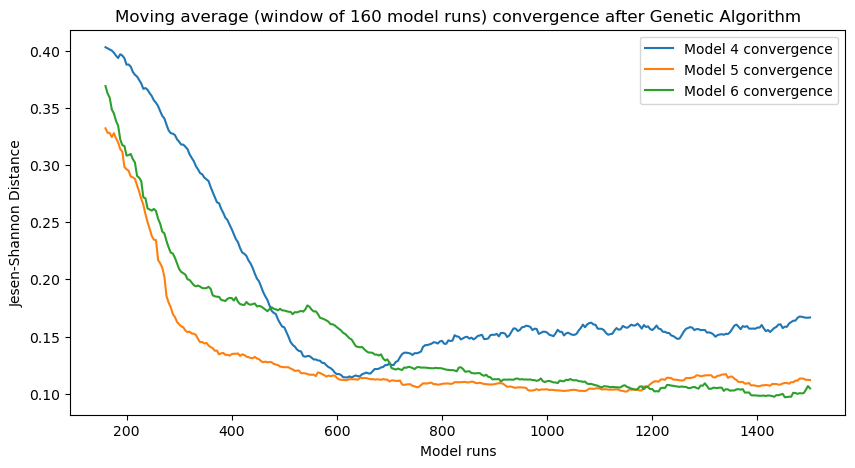

In [7]:
# Moving Averages

window_size = 40

plt.figure(figsize=(10,5))

for idx in range(3, 6):
    stepNo = idx + 1
    x = objFunctionHistory_stepwise[idx]["evaluation"]
    y1 = objFunctionHistory_stepwise[idx]["fitness"]
    y = pd.Series(y1).rolling(window=window_size).mean().to_numpy()

    # print(len(y1))
    # print(len(y))


    plt.plot(x,y, label=(f'Model {stepNo} convergence'))
    plt.title(f'Moving average (window of {window_size*4} model runs) convergence after Genetic Algorithm')
    plt.ylabel('Jesen-Shannon Distance')
    plt.xlabel('Model runs')
    plt.legend()

In [2]:
# Comparing with the longer trajectory and larger tournament size for step 6
objFunctionHistory_Tsize60 = pd.read_csv(f'BSearchresults_GA_step6_Tsize60_2.5k.objectiveFunctionHistory.csv')


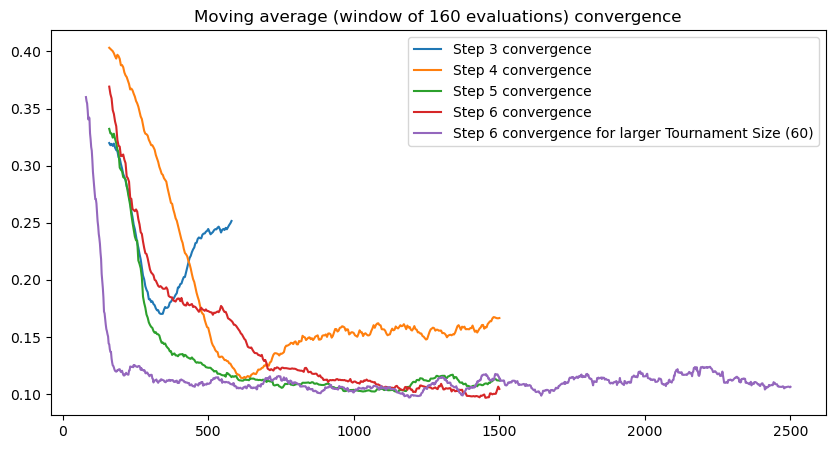

In [5]:
# Moving Averages

window_size = 40

plt.figure(figsize=(10,5))

for idx in range(2, 6):
    stepNo = idx + 1
    x = objFunctionHistory_stepwise[idx]["evaluation"]
    y1 = objFunctionHistory_stepwise[idx]["fitness"]
    y = pd.Series(y1).rolling(window=window_size).mean().to_numpy()

    # print(len(y1))
    # print(len(y))


    plt.plot(x,y, label=(f'Step {stepNo} convergence'))
    plt.title(f'Moving average (window of {window_size*4} evaluations) convergence')
    # plt.

x = objFunctionHistory_Tsize60["evaluation"]
y1 = objFunctionHistory_Tsize60["fitness"]
y = pd.Series(y1).rolling(window=window_size).mean().to_numpy()
plt.plot(x,y, label=(f'Step {stepNo} convergence for larger Tournament Size (60)'))

plt.legend()

# Parameter Study for pooled dist

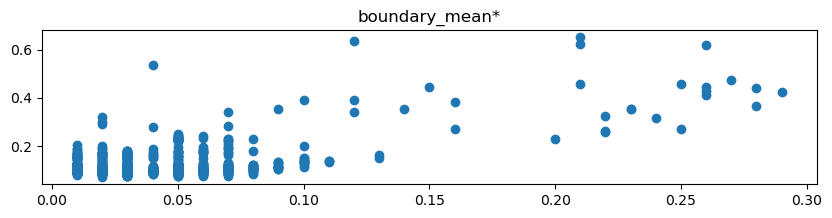

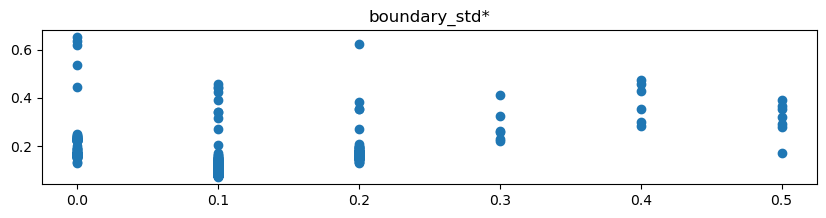

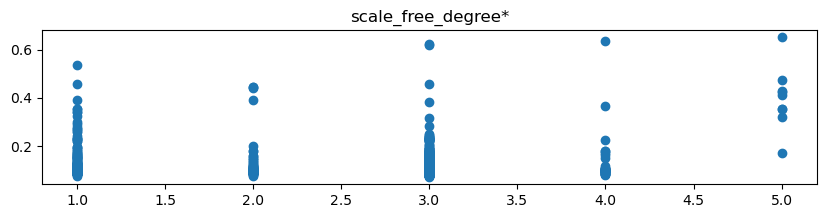

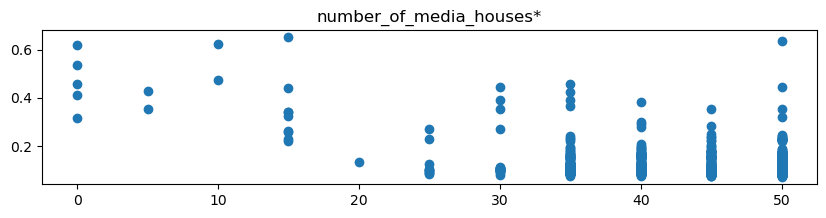

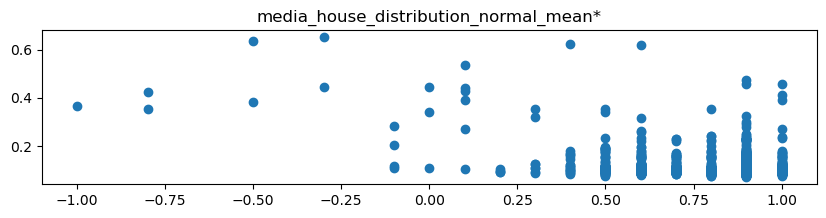

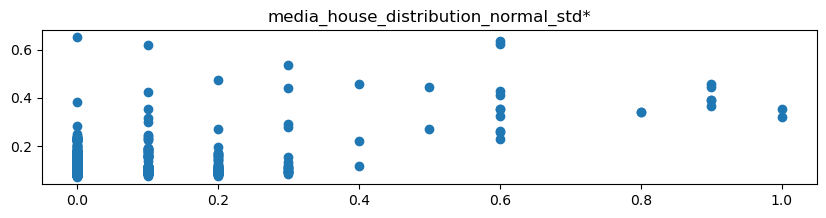

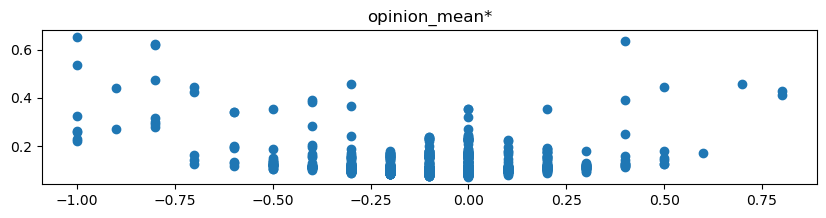

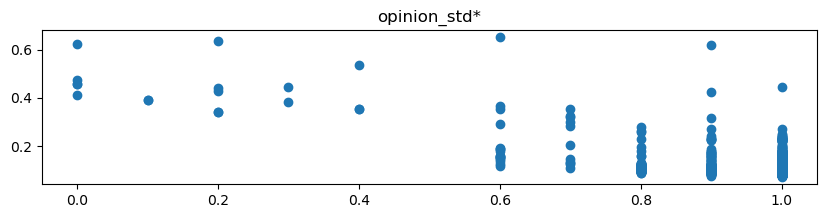

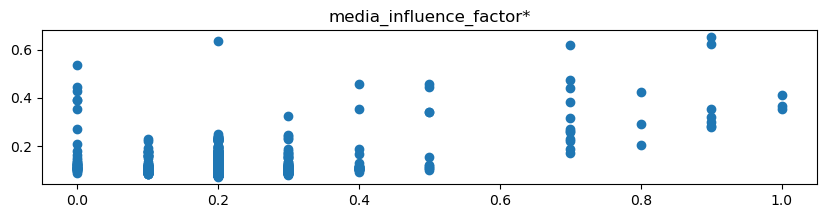

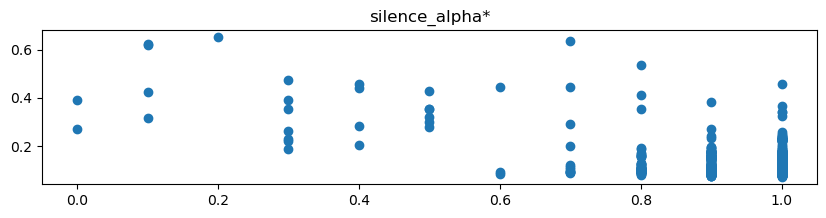

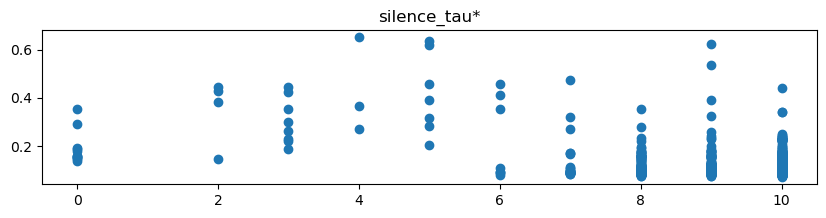

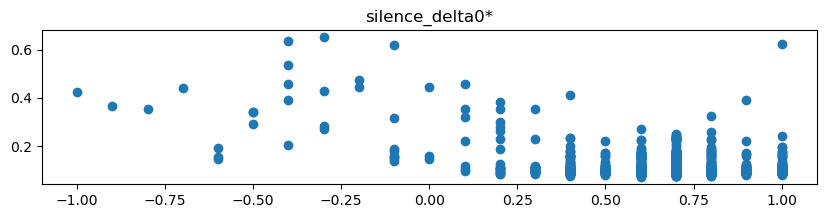

In [41]:
# lets try this for the Psize 60 first
column_names = objFunctionHistory_Tsize60.columns
names_of_params_of_interest = ['boundary_mean*',
      'boundary_std*', 'scale_free_degree*','number_of_media_houses*',
       'media_house_distribution_normal_mean*',
       'media_house_distribution_normal_std*',
       'opinion_mean*', 'opinion_std*',
       'media_influence_factor*', 'silence_alpha*', 'silence_tau*',
       'silence_delta0*']

params_of_interest = objFunctionHistory_Tsize60[names_of_params_of_interest]
# print(params_of_interest)
fitness = objFunctionHistory_Tsize60['fitness']

for param_name in names_of_params_of_interest:
    param_values = objFunctionHistory_Tsize60[param_name]
    # zeros = np.zeros_like(param_values)
    plt.figure(figsize=(10, 2))
    # plt.scatter(param_values, zeros, )
    plt.scatter(param_values, fitness)
    plt.title(param_name)

    
    # for i, val in enumerate(param_values):
    #     this_eval_no=objFunctionHistory_Tsize60['evaluation'].iloc[i]
    #     this_fitness=objFunctionHistory_Tsize60['evaluation'].iloc[i]



In [47]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
import os

# Create output directory if it doesn't exist
os.makedirs('analysis/plots/BehaviorSearch', exist_ok=True)

# Discretizing
threshold_quantile = 0.05
quantile_boundary = objFunctionHistory_Tsize60['fitness'].quantile(threshold_quantile)

# Create binary mask for good solutions
good_mask = objFunctionHistory_Tsize60['fitness'] <= quantile_boundary

# Create a PDF to save all figures
with PdfPages('analysis/plots/BehaviorSearch/pooled_parameter_hit_regions.pdf') as pdf:
    for param_name in names_of_params_of_interest:
        param_values = objFunctionHistory_Tsize60[param_name]
        
        # Get ALL unique values in the parameter
        all_unique_values = np.sort(param_values.unique())
        
        # Count good solutions for each unique value
        good_counts = []
        for val in all_unique_values:
            mask = param_values == val
            good_counts.append(np.sum(good_mask[mask]))
        
        # Reshape for imshow (1 row, multiple columns)
        counts_array = np.array(good_counts).reshape(1, -1)
        
        # Create the 1D color plot
        fig, ax = plt.subplots(figsize=(10, 2))
        
        # Use imshow with extent to show the full parameter range
        im = ax.imshow(counts_array, aspect='auto', cmap='viridis', 
                       extent=[all_unique_values[0], all_unique_values[-1], 0, 1])
        
        ax.set_xlabel('Parameter Value')
        ax.set_yticks([])  # Remove y-axis ticks
        
        # Add x-ticks at the actual parameter values (if not too many)
        if len(all_unique_values) <= 20:  # Only show all ticks if reasonable number
            ax.set_xticks(all_unique_values)
            ax.set_xticklabels([f'{val:.2f}' for val in all_unique_values], rotation=45)
        else:
            # Otherwise show a subset of ticks
            step = max(1, len(all_unique_values) // 10)
            tick_indices = range(0, len(all_unique_values), step)
            ax.set_xticks(all_unique_values[tick_indices])
            ax.set_xticklabels([f'{val:.2f}' for val in all_unique_values[tick_indices]], rotation=45)
        
        ax.set_title(f'{param_name} - Good Solutions (top {threshold_quantile*100}%)')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, label='Number of Good Solutions')
        plt.tight_layout()
        
        # Save the current figure to the PDF
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()  # Close the figure to free memory